In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sqlite3
import seaborn as sns
from datetime import datetime, timedelta

In [69]:
df = pd.read_csv("/content/chemical_process_timeseries.csv")

In [70]:
# 1. GENERATE MOCK CHEMICAL PROCESS DATA (For testing the pipeline)
np.random.seed(42)
time_index = pd.date_range(start="2026-09-01", periods=500, freq="h")

# Normal operating parameters
temperature = np.random.normal(loc=150, scale=5, size=500) # °C
pressure = np.random.normal(loc=50, scale=2, size=500)     # atm
flow_rate = np.random.normal(loc=100, scale=10, size=500)  # L/min

# Injecting anomalies for ChemE analysis
# Anomaly 1: Exothermic runaway (Temperature spikes at hour 200)
temperature[200:220] += np.linspace(0, 40, 20)
# Anomaly 2: Fouling/Scaling (Pressure drops gradually after hour 350)
pressure[350:500] -= np.linspace(0, 15, 150)

# Create DataFrame
df = pd.DataFrame({
    'timestamp': time_index,
    'temperature_c': temperature,
    'pressure_atm': pressure,
    'flow_rate_lmin': flow_rate
})

# Introduce some realistic missing values
df.loc[10:15, 'temperature_c'] = np.nan

print("Data generated. Shape:", df.shape)
df.head()

Data generated. Shape: (500, 4)


,timestamp,temperature_c,pressure_atm,flow_rate_lmin
0,2026-09-01 00:00:00,152.483571,51.852355,113.993554
1,2026-09-01 01:00:00,149.308678,53.818833,109.246337
2,2026-09-01 02:00:00,153.238443,47.202865,100.596304
3,2026-09-01 03:00:00,157.615149,51.125938,93.530632
4,2026-09-01 04:00:00,148.829233,48.698715,106.982233


In [71]:
df.head()

,timestamp,temperature_c,pressure_atm,flow_rate_lmin
0,2026-09-01 00:00:00,152.483571,51.852355,113.993554
1,2026-09-01 01:00:00,149.308678,53.818833,109.246337
2,2026-09-01 02:00:00,153.238443,47.202865,100.596304
3,2026-09-01 03:00:00,157.615149,51.125938,93.530632
4,2026-09-01 04:00:00,148.829233,48.698715,106.982233


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       500 non-null    datetime64[ns]
 1   temperature_c   494 non-null    float64       
 2   pressure_atm    500 non-null    float64       
 3   flow_rate_lmin  500 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 15.8 KB


In [73]:
df.describe()

,timestamp,temperature_c,pressure_atm,flow_rate_lmin
count,500,494.000000,500.000000,500.000000
mean,2026-09-11 09:30:00,150.893792,47.813652,101.084845
min,2026-09-01 00:00:00,133.793663,31.721899,71.037446
25%,2026-09-06 04:45:00,146.614491,46.687235,93.975704
50%,2026-09-11 09:30:00,150.311276,49.043594,101.198058
75%,2026-09-16 14:15:00,153.583284,50.745369,107.547384
max,2026-09-21 19:00:00,190.409371,55.264764,126.016831
std,NaN,6.933266,4.607750,10.102463


In [74]:
df.describe()

,timestamp,temperature_c,pressure_atm,flow_rate_lmin
count,500,494.000000,500.000000,500.000000
mean,2026-09-11 09:30:00,150.893792,47.813652,101.084845
min,2026-09-01 00:00:00,133.793663,31.721899,71.037446
25%,2026-09-06 04:45:00,146.614491,46.687235,93.975704
50%,2026-09-11 09:30:00,150.311276,49.043594,101.198058
75%,2026-09-16 14:15:00,153.583284,50.745369,107.547384
max,2026-09-21 19:00:00,190.409371,55.264764,126.016831
std,NaN,6.933266,4.607750,10.102463


In [75]:
# 1. Check for missing values
print("Missing values before cleaning:\n", df.isnull().sum())

# 2. Forward-fill missing values (standard for time-series sensor data)
df['temperature_c'] = df['temperature_c'].ffill()

# 3. Ensure timestamps are datetime objects
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')

print("\nMissing values after cleaning:\n", df.isnull().sum())

Missing values before cleaning:
 timestamp         0
temperature_c     6
pressure_atm      0
flow_rate_lmin    0
dtype: int64

Missing values after cleaning:
 timestamp         0
temperature_c     0
pressure_atm      0
flow_rate_lmin    0
dtype: int64


In [76]:
# 1. Connect to an in-memory SQLite database
conn = sqlite3.connect(':memory:')
df.to_sql('reactor_data', conn, if_exists='replace', index=False)

# 2. SQL Query 1: Daily Averages (Checking overall trends)
query_daily = """
SELECT
    DATE(timestamp) as op_date,
    ROUND(AVG(temperature_c), 2) as avg_temp,
    ROUND(AVG(pressure_atm), 2) as avg_pressure
FROM reactor_data
GROUP BY op_date
ORDER BY op_date;
"""
daily_summary = pd.read_sql_query(query_daily, conn)
print("--- Daily Operating Averages ---")
display(daily_summary.head())

# 3. SQL Query 2: Fault Detection (Finding the thermal runaway)
query_faults = """
SELECT timestamp, temperature_c, pressure_atm
FROM reactor_data
WHERE temperature_c > 175;
"""
faults = pd.read_sql_query(query_faults, conn)
print("\n--- High Temperature Faults Detected ---")
display(faults.head())

--- Daily Operating Averages ---


,op_date,avg_temp,avg_pressure
0,2026-09-01,150.96,49.75
1,2026-09-02,148.69,49.19
2,2026-09-03,150.48,50.02
3,2026-09-04,149.34,50.19
4,2026-09-05,150.25,50.38



--- High Temperature Faults Detected ---


,timestamp,temperature_c,pressure_atm
0,2026-09-09 17:00:00,188.211026,53.392913
1,2026-09-09 19:00:00,178.835723,49.806574
2,2026-09-09 20:00:00,180.033167,48.910162
3,2026-09-09 21:00:00,180.625377,50.798272
4,2026-09-09 22:00:00,177.897338,49.924731


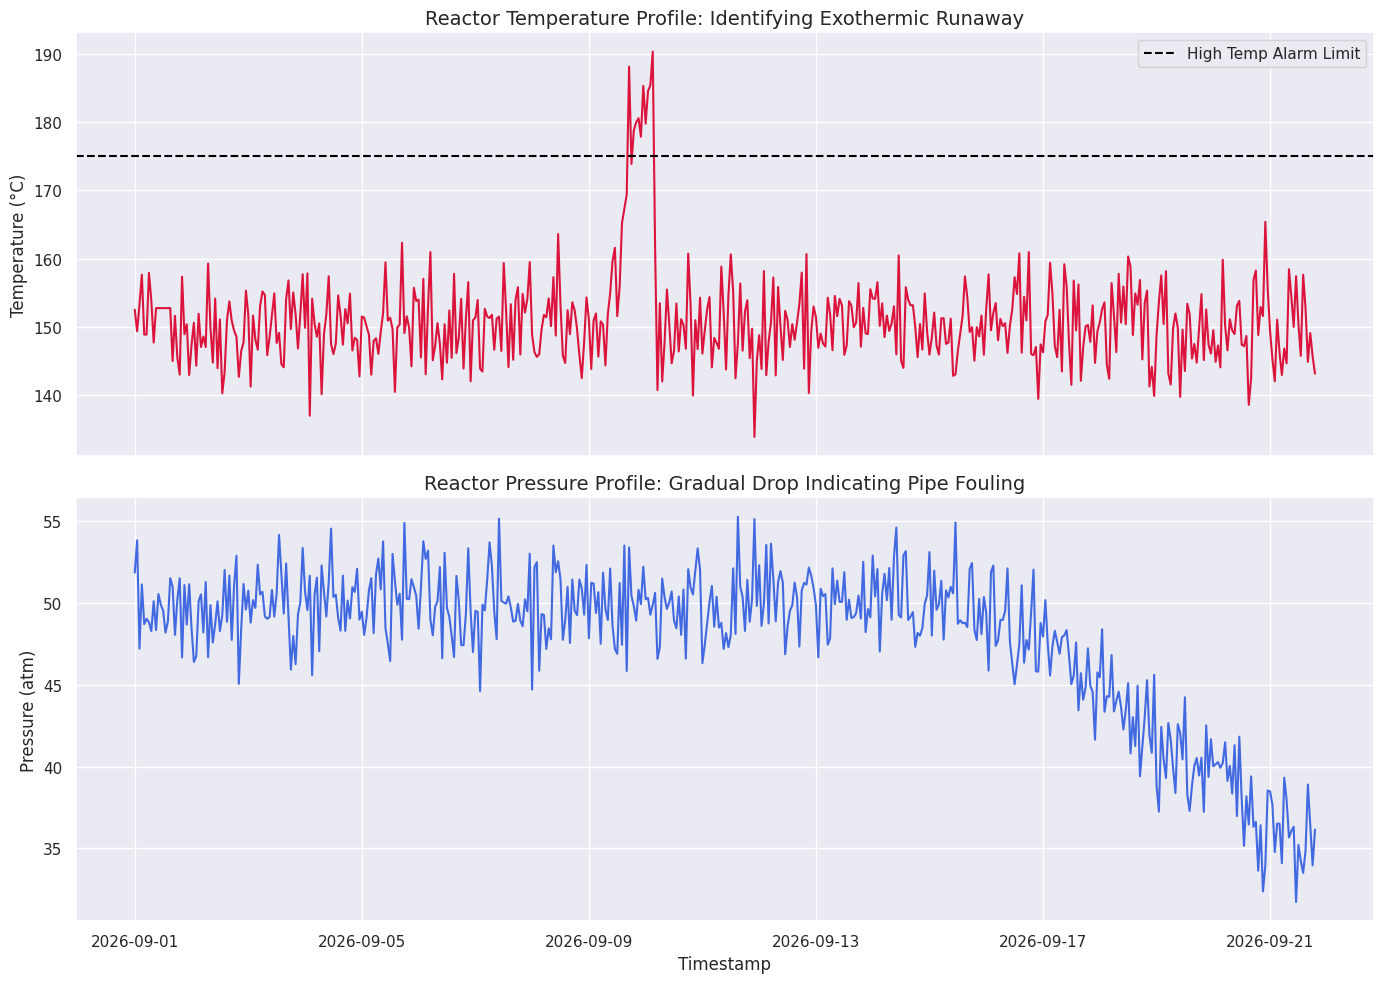

In [80]:
# Set visualization style
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot 1: Temperature Profile (Detecting Thermal Runaway)
sns.lineplot(ax=axes[0], data=df, x='timestamp', y='temperature_c', color='crimson')
axes[0].axhline(175, color='black', linestyle='--', label='High Temp Alarm Limit')
axes[0].set_title('Reactor Temperature Profile: Identifying Exothermic Runaway', fontsize=14)
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend()
# Plot 2: Pressure Profile (Detecting Equipment Degradation)
sns.lineplot(ax=axes[1], data=df, x='timestamp', y='pressure_atm', color='royalblue')
axes[1].set_title('Reactor Pressure Profile: Gradual Drop Indicating Pipe Fouling', fontsize=14)
axes[1].set_ylabel('Pressure (atm)')
axes[1].set_xlabel('Timestamp')

plt.tight_layout()
plt.show()


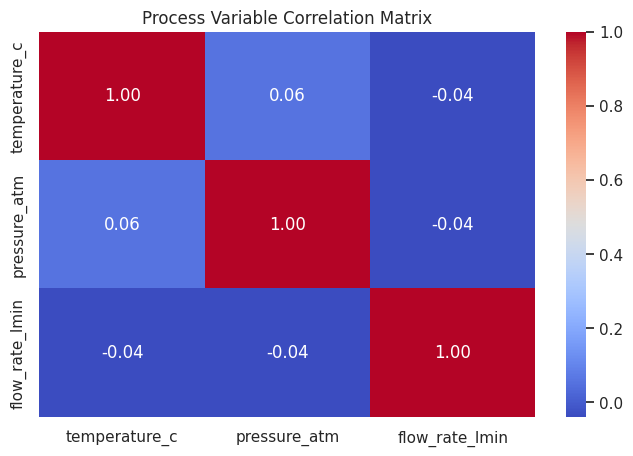

In [79]:
# Correlation Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df[['temperature_c', 'pressure_atm', 'flow_rate_lmin']].corr(),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Process Variable Correlation Matrix')
plt.show()